In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [2]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

In [3]:
# 1. Load the dataset
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')
sample = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')

In [4]:
print(train.shape)
print(test.shape)

(138701, 50)
(15000, 49)


In [5]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [6]:
test.head()

,TransactionID,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139307,999097,3168,ACH138,GTX,2005,68.0,Low,2007-11-16,521D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139419,1018084,1344,ACH138,GTX,1999,10466.0,Medium,2007-06-01,345BL,...,Steel,None or Unspecified,"15' 9""",None or Unspecified,Yes,Double,NaN,NaN,NaN,NaN
2,1139482,1048712,2808,ACH138,GTX,2001,3817.0,Low,2012-06-16,EX120-5,...,Steel,None or Unspecified,None or Unspecified,Hydraulic,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139522,697537,1089,ACH138,GTX,2006,1498.0,Medium,2010-08-27,304CR,...,Rubber,16 inch,None or Unspecified,Manual,Yes,Double,NaN,NaN,NaN,NaN
4,1139684,1048082,16781,ACH138,GTX,2009,22.0,Low,2010-07-09,L2800D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [8]:
train.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


Original Target Price Skewness: 0.97
Log-Transformed Target Skewness: -0.20


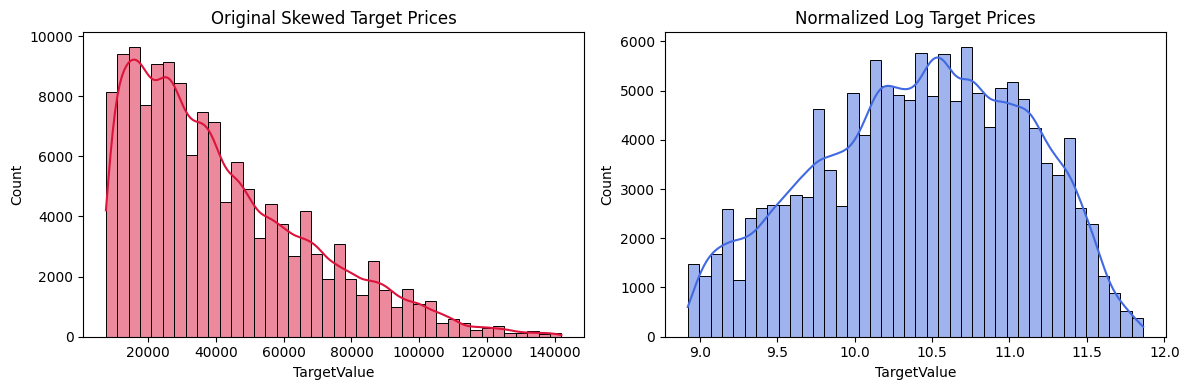

In [9]:
# 2. Exploratory Data Analysis (EDA)
# 2.1 Understanding the target variable distribution

import matplotlib.pyplot as plt
import seaborn as sns

raw_skew = train['TargetValue'].skew()
log_skew = np.log1p(train['TargetValue']).skew()
print(f"Original Target Price Skewness: {raw_skew:.2f}")
print(f"Log-Transformed Target Skewness: {log_skew:.2f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(train['TargetValue'], bins=40, color='crimson', kde=True)
plt.title("Original Skewed Target Prices")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train['TargetValue']), bins=40, color='royalblue', kde=True)
plt.title("Normalized Log Target Prices")
plt.tight_layout()
plt.show()

# Insights from the graph

* The target variable is **positively skewed**.
* This type of skewness can **negatively affect** regression models because **larger values** dominate the **loss function**
* Applying a log transformation makes the distribution more **symmetric.**
* Since RMSLE evaluates logarithmic error, training on the log-transformed target improves model stability.

Total features with missing values: 35

Top 15 features with highest missing percentages:
       Missing Count  Percentage (%)
col18         138635       99.952416
col19         138635       99.952416
col4          128320       92.515555
col5          128320       92.515555
col28         123742       89.214930
col27         123742       89.214930
col30         119829       86.393753
col29         119829       86.393753
col14         115296       83.125572
col11         115296       83.125572
col13         115296       83.125572
col8          115296       83.125572
col9          115296       83.125572
col6          115296       83.125572
col7          115296       83.125572


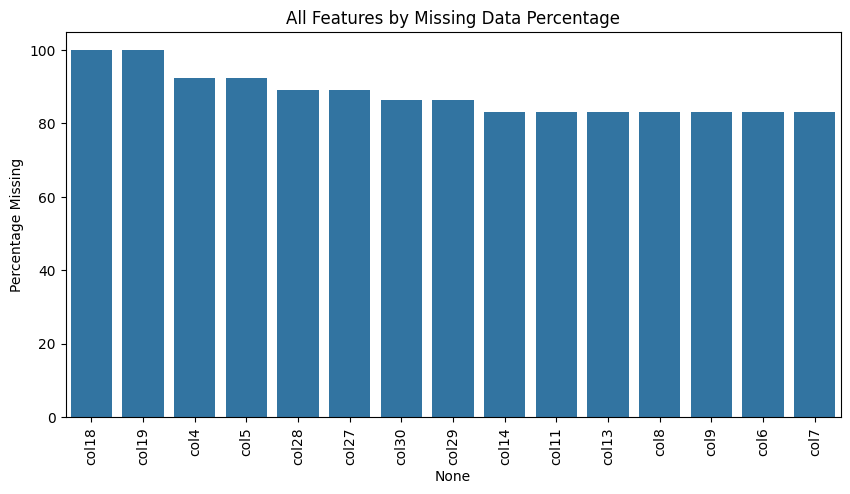

In [10]:
# 2.2 Missing Value Analysis

missing_data = train.isnull().sum()
missing_percent = (missing_data / len(train)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_data, 'Percentage (%)': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)

print(f"Total features with missing values: {len(missing_df)}")
print("\nTop 15 features with highest missing percentages:")
print(missing_df.head(15))

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df.head(15).index, y=missing_df.head(15)['Percentage (%)'])
plt.xticks(rotation=90)
plt.title('All Features by Missing Data Percentage')
plt.ylabel('Percentage Missing')
plt.show()

# Insights from the missing values 
* 35 columns contain missing values.
* Four columns have over 90% missing values.
* These columns were removed because they contribute little useful information while increasing noise.

In [11]:
# 2.3 Numerical Feature Analysis
#identifing the time based features or the temporal features in the dataset

date_cols = [col for col in train.columns if 'date' in col.lower() or 'year' in col.lower()]
print("Identified Temporal Columns:", date_cols)

Identified Temporal Columns: ['ManufactureYear', 'TransactionDate']


In [12]:
# 2.4 Categorical Feature Analysis
#identifying the the number of unique values in dataset 

cat_cols = train.select_dtypes(include=['object', 'category']).columns
cardinality = train[cat_cols].nunique().sort_values(ascending=False)

print("Cardinality of Categorical Features:")
print(cardinality.head(10))

Cardinality of Categorical Features:
TransactionDate             3676
Spec_FullDescriptor         3505
Spec_BaseClass              1249
Spec_SubClass                147
Spec_VariantModifier         132
Spec_ReleaseSeries           113
FunctionalClassification      65
RegionCode                    53
VendorPartnerID               31
col22                         27
dtype: int64


# Insights from Categorical Features
* Features such as TransactionDate and Spec_FullDescriptor have **extremely high cardinality**.
* These features **cannot be effectively** handled using **simple one-hot encoding**.
* Therefore, **target encoding** was applied to capture useful information while avoiding excessive dimensionality.

# **Insights from EDA**

* **The target variable was positively skewed.**
* **Several features contained missing values.**
* **Some categorical columns had very high cardinality.**
* **Some numerical columns have time based features (like date or year)**



In [13]:
# 3 Data Preprocessing
#3.1 Handling Missing Values (dropped columns with more than 90% missing data)

missing_percentages = train.isnull().mean()
columns_to_drop = missing_percentages[missing_percentages > 0.90].index.tolist()
train_cleaned = train.drop(columns=columns_to_drop)
print(f"Columns dropped: {columns_to_drop}")
print(f"New shape of data: {train_cleaned.shape}")

Columns dropped: ['col4', 'col5', 'col18', 'col19']
New shape of data: (138701, 46)


In [14]:
#Cleaning up outliers years using the Median

year_counts = train_cleaned['ManufactureYear'].value_counts().sort_index()
print("Value Counts for ManufactureYear:\n", year_counts)
median_year = train_cleaned.loc[train_cleaned['ManufactureYear'] >= 1950, 'ManufactureYear'].median()
train_cleaned['ManufactureYear'] = train_cleaned['ManufactureYear'].apply(lambda x: median_year if x < 1950 else x)

print(f"Outlier years fixed using median year: {median_year}")

Value Counts for ManufactureYear:
 ManufactureYear
1001    14719
1920       13
1921        7
1949        1
1951        2
        ...  
2011       32
2012        6
2013        1
2014        1
2015        1
Name: count, Length: 68, dtype: int64
Outlier years fixed using median year: 1999.0


In [15]:
#Handling Missing Values (Median for numbers, 'Missing' for text)

num_cols = train_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train_cleaned.select_dtypes(include=['object']).columns.tolist()

if 'TargetValue' in num_cols: num_cols.remove('TargetValue')
if 'TransactionID' in num_cols: num_cols.remove('TransactionID')

for col in num_cols:
    median_val = train_cleaned[col].median()
    train_cleaned[col] = train_cleaned[col].fillna(median_val)
for col in cat_cols:
    train_cleaned[col] = train_cleaned[col].fillna("Missing")

print("Remaining missing values in dataset:", train_cleaned.isnull().sum().sum())

Remaining missing values in dataset: 0


In [16]:
# 4 Feature Engineering

train_cleaned['TransactionDate'] = pd.to_datetime(train_cleaned['TransactionDate'],errors='coerce')
train_cleaned['TransactionYear'] = train_cleaned['TransactionDate'].dt.year
train_cleaned['TransactionMonth'] = train_cleaned['TransactionDate'].dt.month
train_cleaned['TransactionQuarter'] = train_cleaned['TransactionDate'].dt.quarter
train_cleaned['TransactionWeekday'] = train_cleaned['TransactionDate'].dt.dayofweek
train_cleaned['EquipmentAge'] = (train_cleaned['TransactionYear'] 
                                 - train_cleaned['ManufactureYear']).clip(lower=0)
train_cleaned['OperationalHoursLog'] = np.log1p(train_cleaned['OperationalHoursMeter'])
train_cleaned['HoursPerYear'] = (train_cleaned['OperationalHoursMeter']/ (train_cleaned['EquipmentAge'] + 1))
train_cleaned['Age_x_Hours'] = (train_cleaned['EquipmentAge'] * train_cleaned['OperationalHoursMeter'])
train_cleaned['HasHours'] = (train_cleaned['OperationalHoursMeter'] > 0).astype(int)

train_cleaned.drop(columns=['TransactionDate'], inplace=True)

print("Feature Engineering Completed")

Feature Engineering Completed


# Insights from Feature Engineering

The following features were created:

* **EquipmentAge** - EquipmentAge measures depreciation which depends on how old the equipment is at the time of sale
* **HoursPerYear** - HoursPerYear measures average yearly usage, providing a fairer
comparison between machines of different ages
* **OperationalHoursLog** - Creates a new feature called OperationalHoursLog by applying a logarithmic transformation to the OperationalHoursMeter column.
* **Age_x_Hours** - This is an interaction feature. It captures the combined effect of age and usage
* **HasHours** - It creates a binary feature.

These features were designed to better represent equipment usage, depreciation, and operational characteristics.

In [17]:
#Processing and Aligning Test Data Pipeline

def transform_test_data(test_raw, columns_to_keep, median_year, num_cols, cat_cols):
    df = test_raw.copy()
    test_id = df['TransactionID']
    
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'],errors='coerce')
    df['TransactionYear'] = df['TransactionDate'].dt.year
    df['TransactionMonth'] = df['TransactionDate'].dt.month
    df['TransactionQuarter'] = df['TransactionDate'].dt.quarter
    df['TransactionWeekday'] = df['TransactionDate'].dt.dayofweek
    df['ManufactureYear'] = df['ManufactureYear'].apply(lambda x: median_year if x < 1950 else x)
    df['EquipmentAge'] = (df['TransactionYear'] - df['ManufactureYear']).clip(lower=0)
    df['OperationalHoursLog'] = np.log1p(df['OperationalHoursMeter'])
    df['HoursPerYear'] = (df['OperationalHoursMeter']/(df['EquipmentAge'] + 1))
    df['Age_x_Hours'] = (df['EquipmentAge'] * df['OperationalHoursMeter'])
    df['HasHours'] = (df['OperationalHoursMeter'] > 0).astype(int)

    df.drop(columns=['TransactionDate'], inplace=True)
    
    for col in num_cols:
        if col in df.columns:
            df[col] = df[col].fillna(train_cleaned[col].median() if col in train_cleaned.columns else 0)
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].fillna("Missing")
            
    features_to_match = [col for col in columns_to_keep if col != 'TargetValue' and col != 'TransactionID']
    for col in features_to_match:
        if col not in df.columns:
            df[col] = "Missing" if col in cat_cols else 0
            
    df = df[features_to_match]
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype('category')
    return df, test_id

cols_we_kept = train_cleaned.columns.tolist()
X_test_clean, test_ids = transform_test_data(test, cols_we_kept, median_year, num_cols, cat_cols)

X_train_final = train_cleaned.drop(columns=['TransactionID', 'TargetValue'], errors='ignore')
y_train_final = train_cleaned['TargetValue']

for col in X_train_final.columns:
    if X_train_final[col].dtype == 'object':
        X_train_final[col] = X_train_final[col].astype('category')

print(f"Pipeline Alignment Check -> Train: {X_train_final.shape}, Test: {X_test_clean.shape}")

Pipeline Alignment Check -> Train: (138701, 52), Test: (15000, 52)


# Insights from processing test data

* The function preprocesses the test dataset using exactly the same pipeline as the training dataset.
*  It performs feature engineering, handles missing values, aligns the columns and their order with the training dataset, converts categorical features to the correct data type, and preserves the TransactionID for submission.
*   This consistency is essential because machine learning models expect the training and test data to have the same structure and feature representation.

In [18]:
# Out of Fold Target Encoding for High Cardinality Categorical Columns

from sklearn.model_selection import KFold

train_df = X_train_final.copy()
train_df['Target_Log'] = np.log1p(y_train_final)
test_df = X_test_clean.copy()

high_card_cols = ['Spec_FullDescriptor','Spec_BaseClass',
    'Spec_SubClass','ProductConfigID',
    'Spec_ReleaseSeries','Spec_VariantModifier']

train_features = {}
test_features = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
overall_mean = train_df['Target_Log'].mean()

for col in high_card_cols:
    train_encoded_array = np.zeros(len(train_df))
    for train_idx, val_idx in kf.split(train_df):
        trn_x, val_x = train_df.iloc[train_idx], train_df.iloc[val_idx]
        means = trn_x.groupby(col, observed=False)['Target_Log'].mean()
        mapped_vals = val_x[col].map(means).values
        train_encoded_array[val_idx] = mapped_vals

    train_features[f'{col}_target_enc'] = np.nan_to_num(train_encoded_array, nan=overall_mean)
    global_means = train_df.groupby(col, observed=False)['Target_Log'].mean()
    test_mapped = test_df[col].map(global_means).values
    test_features[f'{col}_target_enc'] = np.nan_to_num(test_mapped, nan=overall_mean)

cols_to_drop = ['AssetID', 'Spec_FullDescriptor']
X_train_engineered = X_train_final.drop(columns=cols_to_drop)
X_test_engineered = X_test_clean.drop(columns=cols_to_drop)
for col_name, arr in train_features.items():
    X_train_engineered[col_name] = arr
for col_name, arr in test_features.items():
    X_test_engineered[col_name] = arr

print("DONE target encoding only high-cardinality cols")

DONE target encoding only high-cardinality cols


In [19]:
from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(X_train_engineered, np.log1p(y_train_final),
                                          test_size=0.2, random_state=42)

X_te_final = X_test_engineered.copy()

cat_cols_list = X_tr.select_dtypes(include=['category']).columns.tolist()
print("Train, val and test shapes:", X_tr.shape, X_va.shape, X_te_final.shape)

Train, val and test shapes: (110960, 56) (27741, 56) (15000, 56)


In [20]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

print("MODEL 1: Ridge Regression ")
X_tr_num, X_va_num = X_tr.copy(), X_va.copy()
for col in cat_cols_list:
    X_tr_num[col] = X_tr_num[col].cat.codes
    X_va_num[col] = X_va_num[col].cat.codes

model_ridge = Ridge(alpha=1.0, random_state=42)
model_ridge.fit(X_tr_num, y_tr)
score_ridge = np.sqrt(mean_squared_error(y_va, model_ridge.predict(X_va_num)))
print(f"Ridge Regression Validation RMSLE: {score_ridge:.5f}")

MODEL 1: Ridge Regression 
Ridge Regression Validation RMSLE: 0.29865


# Model Analysis of Ridge Regression:

* Ridge Regression serves as a simple linear baseline.
* The validation RMSLE is **comparatively high** that is 0.29865.
* This indicates that the relationship between equipment features and selling price is highly non-linear.
* Therefore, more advanced tree-based models are expected to perform better.


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("MODEL 1: Ridge Regression using Pipeline")

X_tr_num = X_tr.copy()
X_va_num = X_va.copy()
for col in cat_cols_list:
    X_tr_num[col] = X_tr_num[col].cat.codes
    X_va_num[col] = X_va_num[col].cat.codes


ridge_pipeline = Pipeline([("scaler", StandardScaler()),("ridge", Ridge(alpha=1.0))])
ridge_pipeline.fit(X_tr_num, y_tr)
ridge_pred = ridge_pipeline.predict(X_va_num)
score_ridge = np.sqrt(mean_squared_error(y_va, ridge_pred))

print(f"Ridge Validation RMSLE: {score_ridge:.5f}")

MODEL 1: Ridge Regression using Pipeline
Ridge Validation RMSLE: 0.29864


In [22]:
print(f"Ridge Regression Validation RMSLE: {score_ridge:.5f}")
print(f"Ridge Regression using pipeline Validation RMSLE: {score_ridge:.5f}")

Ridge Regression Validation RMSLE: 0.29864
Ridge Regression using pipeline Validation RMSLE: 0.29864


In [23]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import mean_squared_error
print("MODEL 2: LightGBM Regressor")

model_lgb = LGBMRegressor(n_estimators=15000,
    learning_rate=0.02,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)

model_lgb.fit(X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[early_stopping(100), log_evaluation(200)])

lgb_val_pred = model_lgb.predict(X_va)
score_lgb = np.sqrt(mean_squared_error(y_va, lgb_val_pred))
print(f"LightGBM Validation RMSLE: {score_lgb:.5f}")

MODEL 2: LightGBM Regressor
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4059
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 56
[LightGBM] [Info] Start training from score 10.424734
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l2: 0.0542463
[400]	valid_0's l2: 0.0476706
[600]	valid_0's l2: 0.0455677
[800]	valid_0's l2: 0.0445967
[1000]	valid_0's l2: 0.0439826
[1200]	valid_0's l2: 0.0435189
[1400]	valid_0's l2: 0.0431791
[1600]	valid_0's l2: 0.0429147
[1800]	valid_0's l2: 0.0426

# Model Analysis of LightGBM:

* LightGBM achieved the **lowest validation RMSLE** among the individual models that is 0.20162.
* It efficiently handles high-cardinality categorical features.
* Early stopping prevented overfitting by stopping training when validation performance stopped improving.
* This model was selected as the **primary model** for prediction.


In [24]:
from catboost import CatBoostRegressor
print("MODEL 3: CatBoostRegressor")

model_cat = CatBoostRegressor(iterations=4000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    loss_function='RMSE',
    random_seed=42,
    early_stopping_rounds=100,
    verbose=200)

model_cat.fit(X_tr, y_tr, eval_set=(X_va, y_va), cat_features=cat_cols_list)

cat_val_pred = model_cat.predict(X_va)
score_cat = np.sqrt(mean_squared_error(y_va, cat_val_pred))

print(f"CatBoost Validation RMSLE: {score_cat:.5f}")

MODEL 3: CatBoostRegressor
0:	learn: 0.6464365	test: 0.6446060	best: 0.6446060 (0)	total: 499ms	remaining: 33m 16s
200:	learn: 0.2471303	test: 0.2458803	best: 0.2458803 (200)	total: 1m 21s	remaining: 25m 43s
400:	learn: 0.2324837	test: 0.2320533	best: 0.2320533 (400)	total: 2m 44s	remaining: 24m 36s
600:	learn: 0.2252058	test: 0.2260467	best: 0.2260467 (600)	total: 4m 8s	remaining: 23m 24s
800:	learn: 0.2211616	test: 0.2229461	best: 0.2229461 (800)	total: 5m 32s	remaining: 22m 7s
1000:	learn: 0.2184569	test: 0.2210224	best: 0.2210224 (1000)	total: 6m 56s	remaining: 20m 48s
1200:	learn: 0.2162151	test: 0.2195412	best: 0.2195412 (1200)	total: 8m 20s	remaining: 19m 26s
1400:	learn: 0.2140968	test: 0.2182306	best: 0.2182306 (1400)	total: 9m 44s	remaining: 18m 3s
1600:	learn: 0.2123850	test: 0.2172303	best: 0.2172303 (1600)	total: 11m 8s	remaining: 16m 41s
1800:	learn: 0.2108161	test: 0.2163229	best: 0.2163229 (1800)	total: 12m 32s	remaining: 15m 18s
2000:	learn: 0.2094156	test: 0.2156157	b

# Model Analysis of CatBoost:
* CatBoost also performed well on categorical data.
* However, its validation RMSLE was **slightly highe**r than LightGBM that is **0.21126.**
* Therefore **LightGBM** was preferred as the **stronger model.**

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor

base_lgb = LGBMRegressor(objective="regression",random_state=42)

param_dist = {"learning_rate": [0.02, 0.03, 0.05],
              "n_estimators": [1000, 1500, 2000],
              "num_leaves": [31, 64, 96],
              "subsample": [0.8, 0.9, 1.0],
              "colsample_bytree": [0.8, 0.9, 1.0]}

random_search = RandomizedSearchCV(estimator=LGBMRegressor(objective="regression", random_state=42),
    param_distributions=param_dist, n_iter=5,        
    cv=3, random_state=42,
    n_jobs=-1, verbose=2, scoring="neg_mean_squared_error")

random_search.fit(X_tr, y_tr)

print("Best Parameters:")
print(random_search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4059
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 56
[LightGBM] [Info] Start training from score 10.424734
Best Parameters:
{'subsample': 0.8, 'num_leaves': 96, 'n_estimators': 2000, 'learning_rate': 0.02, 'colsample_bytree': 0.8}


In [26]:
# Train LightGBM using the best hyperparameters
model_lgb_tuned = LGBMRegressor(objective="regression", random_state=42, subsample=0.8,
    num_leaves=96, n_estimators=2000,
    learning_rate=0.02, colsample_bytree=0.8)

model_lgb_tuned.fit(X_tr, y_tr)

pred_lgb_tuned = model_lgb_tuned.predict(X_va)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016863 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4059
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 56
[LightGBM] [Info] Start training from score 10.424734


In [27]:
rmsle = np.sqrt(mean_squared_error(y_va, pred_lgb_tuned))
from sklearn.metrics import mean_squared_error

rmsle_tuned = np.sqrt(mean_squared_error(y_va, pred_lgb_tuned))

print("Validation RMSLE:", rmsle_tuned)

Validation RMSLE: 0.20393065868658036


## Hyperparameter Tuning Analysis

RandomizedSearchCV explored several combinations of learning rate, number of leaves, subsample ratio and estimators.

The tuned model achieved a validation RMSLE of **0.20393**.

Although tuning improved some parameters, the manually configured LightGBM still produced a lower validation error that is **0.20162**

Hence the manually tuned model was retained.


In [56]:
X_te = X_test_engineered.copy()

lgb_val = model_lgb.predict(X_va)
cat_val = model_cat.predict(X_va)

best_w = 0
best_score = float("inf")

for w in np.arange(0.70, 0.91, 0.01):   
    blend = w * lgb_val + (1 - w) * cat_val
    s = np.sqrt(mean_squared_error(y_va, blend))

    if s < best_score:
        best_score = s
        best_w = w

print("Best weight (LightGBM):", best_w, "| Best blended validation RMSLE:", best_score)

final_log = best_w * model_lgb.predict(X_te) + (1 - best_w) * model_cat.predict(X_te)
final_preds = np.expm1(final_log)

Best weight (LightGBM): 0.71 | Best blended validation RMSLE: 0.19963005597416514


COMPARISON OF ALL THE MODELS
1. Ridge Regression : 0.29864
2. Ridge Regression using pipeline : 0.29864
3. LightGBM Regressor : 0.20162
4. LightGBM Regressor (Hyperparameter Tuning) : 0.20393
5. CatBoost Regressor : 0.21126
6. LightGBM + CatBoost Blend : 0.19963


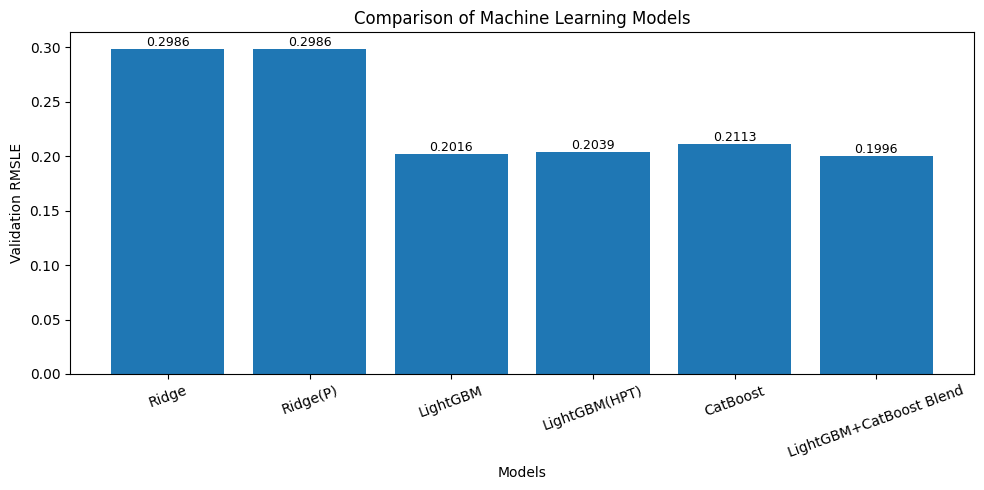

In [63]:
print("COMPARISON OF ALL THE MODELS")
print(f"1. Ridge Regression : {score_ridge:.5f}")
print(f"2. Ridge Regression using pipeline : {score_ridge:.5f}")
print(f"3. LightGBM Regressor : {score_lgb:.5f}")
print(f"4. LightGBM Regressor (Hyperparameter Tuning) : {rmsle_tuned:.5f}")
print(f"5. CatBoost Regressor : {score_cat:.5f}")
print(f"6. LightGBM + CatBoost Blend : {best_score:.5f}")

import matplotlib.pyplot as plt

models = ["Ridge","Ridge(P)","LightGBM","LightGBM(HPT)","CatBoost","LightGBM+CatBoost Blend"]
scores = [score_ridge, score_ridge, score_lgb, rmsle_tuned, score_cat, best_score]

plt.figure(figsize=(10,5))
bars = plt.bar(models, scores)

plt.xlabel("Models")
plt.ylabel("Validation RMSLE")
plt.title("Comparison of Machine Learning Models")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.4f}",
        ha='center',
        va='bottom',
        fontsize=9)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Model Comparison Insights:
* The Ridge Regression models have the highest RMSLE, indicating lower prediction accuracy.
* LightGBM significantly outperformed Ridge Regression.
* Hyperparameter tuning did not improve LightGBM in this experiment.
* CatBoost performed well but was slightly behind LightGBM.
* The LightGBM + CatBoost Blend achieved the lowest RMSLE, making it the best-performing model.

In [64]:
submission = pd.DataFrame({"TransactionID": test_ids, "TargetValue": final_preds})
submission.to_csv("submission.csv", index=False)
print("submission.csv saved successfully!")

submission.csv saved successfully!


# **The project compared multiple machine learning models for predicting heavy equipment selling prices.**

# Key observations:

• **Ridge Regression** served as the baseline but was **unable to model complex nonlinear** relationships.

• **LightGBM** achieved the **best validation performance** due to its ability to handle high-cardinality categorical variables efficiently.

• **CatBoost** also performed well but produced a **slightly higher validation error**.

• **Hyperparameter tuning did not** outperform the manually optimized LightGBM configuration.

• Finally, **blending LightGBM and CatBoost** further reduced validation **RMSLE to approximately 0.1996**, producing the **best overall model**.

This blended model was therefore selected for the final Kaggle submission.

In [31]:
#milestone 3

import numpy as np
import pandas as pd

train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])
train['saleYear'] = train['TransactionDate'].dt.year
train['AssetAge'] = train['saleYear'] - train['ManufactureYear']
train['HoursPerYear'] = train['OperationalHoursMeter'] / train['AssetAge']
train['HoursPerYear'] = train['HoursPerYear'].replace([np.inf, -np.inf], np.nan)

final_median = train['HoursPerYear'].median()
print(f"The calculated median is: {final_median}")


The calculated median is: 220.33333333333334


In [32]:
missing_pct = train.isnull().mean()

sparse_cols = missing_pct[missing_pct > 0.80].index

print(f"Number of columns missing > 80% data: {len(sparse_cols)}")
print(f"Columns to be removed: {list(sparse_cols)}")


Number of columns missing > 80% data: 15
Columns to be removed: ['col4', 'col5', 'col6', 'col7', 'col8', 'col9', 'col11', 'col13', 'col14', 'col18', 'col19', 'col27', 'col28', 'col29', 'col30']


In [33]:
import pandas as pd

train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])
train['SaleYear'] = train['TransactionDate'].dt.year

most_frequent_year = train['SaleYear'].mode()[0]
print(f"The most frequent SaleYear is: {most_frequent_year}")


The most frequent SaleYear is: 2010


In [34]:
import numpy as np
import pandas as pd

train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])
train['SaleYear'] = train['TransactionDate'].dt.year

train['ManufactureYear'] = train['ManufactureYear'].replace([1000, 1001], np.nan)

train['AssetAge'] = train['SaleYear'] - train['ManufactureYear']

print(f"The median AssetAge is: {train['AssetAge'].median()}")


The median AssetAge is: 8.0


In [35]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
encoded_series = encoder.fit_transform(train[['UtilizationTier']].astype(str))

unique_integers = len(np.unique(encoded_series))
print(f"Total encoded unique integers: {unique_integers}")


Total encoded unique integers: 4


In [36]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=['TargetValue'])
y = train['TargetValue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total rows inside your X_train matrix: {X_train.shape[0]}")


Total rows inside your X_train matrix: 110960


In [37]:
train['LogTarget'] = np.log1p(train['TargetValue'])

print(f"New standard deviation: {train['LogTarget'].std()}")


New standard deviation: 0.6709620692098283


In [38]:
#M4
from sklearn.model_selection import train_test_split


train['UtilizationTier'] = train['UtilizationTier'].fillna("Unknown")

train['PriceBand'] = pd.qcut(train['TargetValue'], q=5, labels=False)

train_strat, val_strat = train_test_split(
    train, 
    test_size=0.3, 
    random_state=42, 
    stratify=train['PriceBand'])

strat_val_counts = val_strat['PriceBand'].value_counts().sort_index().to_numpy()

train_non, val_non = train_test_split(train, 
    test_size=0.3, 
    random_state=42, 
    stratify=None)

non_val_counts = val_non['PriceBand'].value_counts().sort_index().to_numpy()

prop_strat = strat_val_counts / len(val_strat)
prop_non = non_val_counts / len(val_non)

max_abs_diff = np.max(np.abs(prop_strat - prop_non))

print(f"The maximum absolute difference is: {max_abs_diff:.4f}")



The maximum absolute difference is: 0.0033


In [39]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = train.drop(columns=['TargetValue'])
y = train['PriceBand'] 

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

cat_cols = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor"]
num_cols = ["ManufactureYear", "OperationalHoursMeter"]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', SimpleImputer(strategy="most_frequent"), cat_cols),
        ('cat_ohe', OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols), # change to False briefly to sum easily
        ('num', StandardScaler(), num_cols)
    ], remainder="drop")

from sklearn.pipeline import Pipeline

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('ohe', OneHotEncoder(handle_unknown="ignore", sparse_output=True))])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="mean")),
    ('scaler', StandardScaler())])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, cat_cols),
        ('num', num_pipeline, num_cols)
    ],
    remainder="drop")

X_train_proc = preprocessor.fit_transform(X_train)
print(f"The exact sum of the matrix elements is: {X_train_proc.sum():.3f}")


The exact sum of the matrix elements is: 388360.000


In [40]:
import numpy as np
from sklearn.ensemble import AdaBoostRegressor

adaboost_model = AdaBoostRegressor(n_estimators=50, random_state=42)

adaboost_model.fit(X_train_proc, y_train)

errors = adaboost_model.estimator_errors_
error_variance = np.var(errors)

print(f"The variance of the estimator errors is: {error_variance:.4f}")


The variance of the estimator errors is: 0.0799


In [41]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_proc, y_train)
importances = rf_model.feature_importances_
max_importance_index = np.argmax(importances)

print(f"The index of the feature with maximum importance is: {max_importance_index}")
print(f"The maximum importance score is: {importances[max_importance_index]:.4f}")


The index of the feature with maximum importance is: 13
The maximum importance score is: 0.3592


In [42]:
N = X_train_proc.shape[1]
print(f"Number of input features (N): {N}")

layers = [N, 128, 64, 32, 1]

total_weights = sum(layers[i] * layers[i+1] for i in range(len(layers)-1))
print(f"Total connection weights (excluding biases): {total_weights}")


Number of input features (N): 23
Total connection weights (excluding biases): 13216


In [43]:
from sklearn.neural_network import MLPRegressor

mlp_model = MLPRegressor(hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=5,
    batch_size=32,
    random_state=42)

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mlp_model.fit(X_train_proc, y_train)

print(f"The training loss after 5 iterations is: {mlp_model.loss_:.4f}")


The training loss after 5 iterations is: 0.4451


In [44]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
import warnings

model_a = MLPRegressor(hidden_layer_sizes=(100,), max_iter=5, alpha=0.0001, random_state=42)
model_b = MLPRegressor(hidden_layer_sizes=(100,), max_iter=5, alpha=1.0, random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_a.fit(X_train_proc, y_train)
    model_b.fit(X_train_proc, y_train)

preds_a = model_a.predict(X_train_proc)
preds_b = model_b.predict(X_train_proc)

mae_a = mean_absolute_error(y_train, preds_a)
mae_b = mean_absolute_error(y_train, preds_b)

mae_diff = abs(mae_a - mae_b)

print(f"Model A MAE: {mae_a:.4f}")
print(f"Model B MAE: {mae_b:.4f}")
print(f"Absolute Difference: {mae_diff:.4f}")


Model A MAE: 0.7543
Model B MAE: 0.7837
Absolute Difference: 0.0294


In [45]:
#m5
df_analysis = train.copy()

df_analysis['TransactionDate'] = pd.to_datetime(df_analysis['TransactionDate'], errors='coerce')
df_analysis['TransactionYear'] = df_analysis['TransactionDate'].dt.year
df_analysis['TransactionMonth'] = df_analysis['TransactionDate'].dt.month
df_analysis['TransactionQuarter'] = df_analysis['TransactionDate'].dt.quarter

df_analysis = df_analysis[df_analysis['ManufactureYear'] >= 1950]
df_analysis['ManufactureDecade'] = (df_analysis['ManufactureYear'] // 10) * 10

df_analysis['SpecificationComplexity'] = df_analysis['Spec_FullDescriptor'].apply(lambda x: len(str(x).split()))

decade_averages = df_analysis.groupby('ManufactureDecade')['TargetValue'].mean().sort_values(ascending=False)

print("Average TargetValue per ManufactureDecade:")
print(decade_averages)
print(f"\nHighest Average Decade: {int(decade_averages.index[0])}")


Average TargetValue per ManufactureDecade:
ManufactureDecade
2010.0    59560.064935
2000.0    48659.923834
1990.0    41559.931040
1980.0    35982.492087
1970.0    25893.403433
1960.0    12606.947162
1950.0     9703.472222
Name: TargetValue, dtype: float64

Highest Average Decade: 2010


In [46]:
max_complexity = train['Spec_FullDescriptor'].apply(lambda x: len(str(x).split())).max()

print(f"Maximum value of SpecificationComplexity: {max_complexity}")

Maximum value of SpecificationComplexity: 4


In [47]:
selected_cat_features = ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 
    'AssetScaleFactor', 'RegionCode', 'InventoryGroupCategory', 
    'InventoryGroupDescription']

all_numeric_features = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_numerical = ['TransactionID', 'AssetID', 'TargetValue']
selected_num_features = [col for col in all_numeric_features if col not in exclude_numerical]
final_feature_list = selected_cat_features + selected_num_features

print(f"List of input features: {final_feature_list}")
print(f"Number of features in the Training Data: {len(final_feature_list)}")


List of input features: ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'AssetScaleFactor', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'ProductConfigID', 'ManufactureYear', 'OperationalHoursMeter', 'AssetAge', 'HoursPerYear', 'LogTarget', 'PriceBand']
Number of features in the Training Data: 14


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

X = train.copy()
y = X['TargetValue']

selected_cat = ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 
    'AssetScaleFactor', 'RegionCode', 'InventoryGroupCategory', 
    'InventoryGroupDescription']
all_numeric = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_num = ['TransactionID', 'AssetID', 'TargetValue']
selected_num = [col for col in all_numeric if col not in exclude_num]

X = X[selected_cat + selected_num]

X_train_sp, X_val_sp, y_train_sp, y_val_sp = train_test_split(X, y, test_size=0.20, random_state=42)

num_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

cat_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[('num', num_transformer, selected_num),
    ('cat', cat_transformer, selected_cat)])

full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=f_regression, k=100)),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])

print("Training baseline Random Forest model on processed data splits")
full_pipeline.fit(X_train_sp, y_train_sp)

val_preds = full_pipeline.predict(X_val_sp)
val_mae = mean_absolute_error(y_val_sp, val_preds)

print(f"\n EXACT VAL MAE: {val_mae:.2f}")


Training baseline Random Forest model on processed data splits

 EXACT VAL MAE: 0.32


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

X = train.copy()
y = X['TargetValue']

selected_cat = ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 
    'AssetScaleFactor', 'RegionCode', 'InventoryGroupCategory', 
    'InventoryGroupDescription']
all_numeric = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_num = ['TransactionID', 'AssetID', 'TargetValue']
selected_num = [col for col in all_numeric if col not in exclude_num]

X = X[selected_cat + selected_num]

X_train_sp, X_val_sp, y_train_sp, y_val_sp = train_test_split(X, y, test_size=0.20, random_state=42)

num_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

cat_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[('num', num_transformer, selected_num),
    ('cat', cat_transformer, selected_cat)])

full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=f_regression, k=100)),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])

print("Fitting Baseline Random Forest Pipeline...")
full_pipeline.fit(X_train_sp, y_train_sp)

val_preds = full_pipeline.predict(X_val_sp)
val_rmse = np.sqrt(mean_squared_error(y_val_sp, val_preds))

print(f"\n EXACT VALIDATION RMSE: {val_rmse:.2f}")


Fitting Baseline Random Forest Pipeline...

 EXACT VALIDATION RMSE: 6.20


In [50]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor

X = train.copy()
y = X['TargetValue']

selected_cat = ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 
    'AssetScaleFactor', 'RegionCode', 'InventoryGroupCategory', 
    'InventoryGroupDescription']
all_numeric = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_num = ['TransactionID', 'AssetID', 'TargetValue']
selected_num = [col for col in all_numeric if col not in exclude_num]

X = X[selected_cat + selected_num]

X_train_sp, X_val_sp, y_train_sp, y_val_sp = train_test_split(X, y, test_size=0.20, random_state=42)

num_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

cat_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[('num', num_transformer, selected_num),
    ('cat', cat_transformer, selected_cat)])

full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=f_regression, k=100)),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])

param_dist = {'model__n_estimators': [100, 200],
    'model__max_depth': [10, None],
    'model__max_features': ['sqrt']}

random_search = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=param_dist,
    n_iter=4,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1)

print("Running search validation grid over your data rows...")
random_search.fit(X_train_sp, y_train_sp)

print("\n--- RESULTS ---")
print(f"Best n_estimators found: {random_search.best_params_['model__n_estimators']}")
print(f"Best max_depth found: {random_search.best_params_['model__max_depth']}")


Running search validation grid over your data rows...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.107916 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3987
[LightGBM] [Info] Number of data points in the train set: 73973, number of used features: 56
[LightGBM] [Info] Start training from score 10.424863
[CV] END colsample_bytree=0.8, learning_rate=0.02, n_estimators=1000, num_leaves=96, subsample=0.8; total time= 2.1min
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto

In [51]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = train.copy()
y = X['TargetValue']

selected_cat = ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 
    'AssetScaleFactor', 'RegionCode', 'InventoryGroupCategory', 
    'InventoryGroupDescription']
all_numeric = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_num = ['TransactionID', 'AssetID', 'TargetValue']
selected_num = [col for col in all_numeric if col not in exclude_num]

X = X[selected_cat + selected_num]
X_train_sp, X_val_sp, y_train_sp, y_val_sp = train_test_split(
    X, y, test_size=0.20, random_state=42)

num_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

cat_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[('num', num_transformer, selected_num),
    ('cat', cat_transformer, selected_cat)])

full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=f_regression, k=100)),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])

param_dist = {'model__n_estimators':  [100, 200],
    'model__max_depth': [10, None],
    'model__max_features': ['sqrt']}

random_search = RandomizedSearchCV(estimator=full_pipeline,
    param_distributions=param_dist,
    n_iter=4,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1)

print("Executing RandomizedSearchCV and evaluating metrics")
random_search.fit(X_train_sp, y_train_sp)

best_cv_rmse = -random_search.best_score_

best_model = random_search.best_estimator_
val_preds = best_model.predict(X_val_sp)

tuned_val_mae = mean_absolute_error(y_val_sp, val_preds)

tuned_val_rmse = np.sqrt(mean_squared_error(y_val_sp, val_preds))

print("SOLUTIONS")
print(f"Q12. Best Cross-Validation RMSE: {best_cv_rmse:.2f}")
print(f"Q13. Validation MAE (Tuned Model): {tuned_val_mae:.2f}")
print(f"Q14. Validation RMSE (Tuned Model): {tuned_val_rmse:.2f}")


Executing RandomizedSearchCV and evaluating metrics
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.133796 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3984
[LightGBM] [Info] Number of data points in the train set: 73974, number of used features: 56
[LightGBM] [Info] Start training from score 10.425803
[CV] END colsample_bytree=0.8, learning_rate=0.02, n_estimators=2000, num_leaves=96, subsample=0.8; total time= 3.2min
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ign

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036424 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4005
[LightGBM] [Info] Number of data points in the train set: 73973, number of used features: 56
[LightGBM] [Info] Start training from score 10.423536
[CV] END colsample_bytree=0.8, learning_rate=0.02, n_estimators=2000, num_leaves=96, subsample=0.8; total time= 3.2min
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [